# 03: 0.9C DC Baseline — End-to-End Protocol Simulation

**Goal**: Validate the complete Phase 0 → 1 → 2 → 3 protocol pipeline on a pure-DC case before introducing AC.

**Ground truth** (from experimental dataset, LG INR18650 MJ1, 20°C ambient):
- CC time: 49 min 29 s
- CV time: 65 min 22 s  
- Total charge time: 114 min 51 s
- T_max (surface, pt100): 34.17°C

**Simulation setup**:
- Model: SPMe with lumped thermal
- Parameter set: Chen2020 (LG M50, chemistry-proximate baseline, 5.0 Ah)
- Ambient temperature: 20°C (293.15 K)
- Current normalization: C-rate (0.9C charge = 0.9 × nominal_capacity)

**Protocol**:
1. Phase 0: 1C discharge to 2.5V, then CV at 2.5V until current drops to 25 mA → SOC=0
2. Phase 1: Rest for 3805 s (63 min 25 s) → thermal and electrochemical relaxation
3. Phase 2: CC charge at 0.9C until terminal voltage reaches 4.2V
4. Phase 3: CV at 4.2V, current limit 1C, until current drops to 50 mA → SOC=1

**Expected systematic bias**: T_max simulation (cell volume-averaged) vs experiment (surface pt100) may differ by 1-2°C. Do not tune parameters to force agreement.

In [1]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt

# Model: SPMe with lumped thermal
model = pybamm.lithium_ion.SPMe(options={"thermal": "lumped"})

# Parameter set: Chen2020
parameter_values = pybamm.ParameterValues("Chen2020")

# Check key defaults
print("=== Key thermal & voltage parameters (Chen2020 defaults) ===")
keys_to_check = [
    "Ambient temperature [K]",
    "Initial temperature [K]",
    "Upper voltage cut-off [V]",
    "Lower voltage cut-off [V]",
    "Nominal cell capacity [A.h]",
    "Total heat transfer coefficient [W.m-2.K-1]",
]
for k in keys_to_check:
    print(f"  {k}: {parameter_values[k]}")

=== Key thermal & voltage parameters (Chen2020 defaults) ===
  Ambient temperature [K]: 298.15
  Initial temperature [K]: 298.15
  Upper voltage cut-off [V]: 4.2
  Lower voltage cut-off [V]: 2.5
  Nominal cell capacity [A.h]: 5.0
  Total heat transfer coefficient [W.m-2.K-1]: 10.0


In [2]:
# Override ambient and initial temperature to 20°C = 293.15 K
T_ambient_K = 273.15 + 20  # 293.15 K

parameter_values["Ambient temperature [K]"] = T_ambient_K
parameter_values["Initial temperature [K]"] = T_ambient_K

# Verify
print(f"Ambient temperature: {parameter_values['Ambient temperature [K]']} K "
      f"({parameter_values['Ambient temperature [K]'] - 273.15:.1f}°C)")
print(f"Initial temperature: {parameter_values['Initial temperature [K]']} K "
      f"({parameter_values['Initial temperature [K]'] - 273.15:.1f}°C)")

Ambient temperature: 293.15 K (20.0°C)
Initial temperature: 293.15 K (20.0°C)


In [4]:
# Four-phase protocol as Experiment string
experiment = pybamm.Experiment([
    # ---- Phase 0: Discharge to SOC=0 ----
    "Discharge at 1C until 2.5 V",
    "Hold at 2.5 V until 25 mA",
    
    # ---- Phase 1: Rest for 3805 s (63 min 25 s) ----
    "Rest for 3805 seconds",


    # ---- Phase 2: CC charge to 4.2V at 0.9C ----
    "Charge at 0.9C until 4.2 V",
    
    # ---- Phase 3: CV at 4.2V until 50 mA ----
    "Hold at 4.2 V until 50 mA",
])

print("Experiment steps:")
for i, step in enumerate(experiment.operating_conditions_steps, start=1):
    print(f"  [{i}] {step}")

Experiment steps:


AttributeError: 'Experiment' object has no attribute 'operating_conditions_steps'

In [5]:
# Build simulation
sim = pybamm.Simulation(
    model,
    parameter_values=parameter_values,
    experiment=experiment,
)

# Run
import time
t_start = time.time()
solution = sim.solve()
wall_time = time.time() - t_start

print(f"\nSimulation completed in {wall_time:.1f} s wall-clock.")
print(f"Simulated time: {solution.t[-1]:.1f} s ({solution.t[-1]/60:.1f} min)")
print(f"Number of output points: {len(solution.t)}")


Simulation completed in 0.8 s wall-clock.
Simulated time: 16282.1 s (271.4 min)
Number of output points: 379


In [6]:
# Each Experiment step produces a "cycle" in the solution
# Inspect phase-by-phase to diagnose

print("=== Solution cycles (= Experiment steps) ===")
print(f"Total cycles: {len(solution.cycles)}")
print()

phase_names = [
    "Phase 0a: Discharge to 2.5V",
    "Phase 0b: CV hold 2.5V until 25 mA",
    "Phase 1:  Rest 3805 s",
    "Phase 2:  Charge 0.9C to 4.2V",
    "Phase 3:  CV hold 4.2V until 50 mA",
]

for i, cycle in enumerate(solution.cycles):
    t_start = cycle.t[0]
    t_end = cycle.t[-1]
    duration = t_end - t_start
    V_start = cycle["Terminal voltage [V]"].entries[0]
    V_end = cycle["Terminal voltage [V]"].entries[-1]
    I_start = cycle["Current [A]"].entries[0]
    I_end = cycle["Current [A]"].entries[-1]
    T_start = cycle["X-averaged cell temperature [K]"].entries[0] - 273.15
    T_end = cycle["X-averaged cell temperature [K]"].entries[-1] - 273.15
    
    name = phase_names[i] if i < len(phase_names) else f"Extra cycle {i}"
    print(f"{name}")
    print(f"  Duration: {duration:.1f} s ({duration/60:.2f} min)")
    print(f"  V: {V_start:.4f} → {V_end:.4f} V")
    print(f"  I: {I_start:.4f} → {I_end:.4f} A")
    print(f"  T_cell: {T_start:.2f} → {T_end:.2f} °C")
    print(f"  Points: {len(cycle.t)}")
    print()

=== Solution cycles (= Experiment steps) ===
Total cycles: 5

Phase 0a: Discharge to 2.5V
  Duration: 3560.5 s (59.34 min)
  V: 4.0247 → 2.5000 V
  I: 5.0000 → 5.0000 A
  T_cell: 20.00 → 34.25 °C
  Points: 99

Phase 0b: CV hold 2.5V until 25 mA
  Duration: 837.6 s (13.96 min)
  V: 2.5000 → 2.5000 V
  I: 5.0000 → 0.0250 A
  T_cell: 34.25 → 25.51 °C
  Points: 85

Phase 1:  Rest 3805 s
  Duration: 3805.0 s (63.42 min)
  V: 2.5019 → 2.5089 V
  I: 0.0000 → 0.0000 A
  T_cell: 25.51 → 20.03 °C
  Points: 33

Phase 2:  Charge 0.9C to 4.2V
  Duration: 2934.5 s (48.91 min)
  V: 2.6897 → 4.2000 V
  I: -4.5000 → -4.5000 A
  T_cell: 20.03 → 31.52 °C
  Points: 79

Phase 3:  CV hold 4.2V until 50 mA
  Duration: 5144.6 s (85.74 min)
  V: 4.2000 → 4.2000 V
  I: -4.5000 → -0.0500 A
  T_cell: 31.52 → 20.09 °C
  Points: 83



In [9]:
# Extract experimental ground truth
exp_gt = {
    "CC_time_min": 49 + 29/60,    # 49 min 29 s
    "CV_time_min": 65 + 22/60,    # 65 min 22 s
    "Total_charge_time_min": (49 + 29/60) + (65 + 22/60),
    "T_max_C": 34.17,
    "Nominal_Q_mAh": 3303,
}

# Extract simulation results
sim_results = {}

# Phase 2 duration (CC charge to 4.2V)
phase2 = solution.cycles[3]  # 0-indexed: 0a, 0b, 1, 2, 3
sim_results["CC_time_min"] = (phase2.t[-1] - phase2.t[0]) / 60

# Phase 3 duration (CV tail)
phase3 = solution.cycles[4]
sim_results["CV_time_min"] = (phase3.t[-1] - phase3.t[0]) / 60
sim_results["Total_charge_time_min"] = sim_results["CC_time_min"] + sim_results["CV_time_min"]

# T_max during Phase 2 + Phase 3 (the charging portion of the protocol)
T_p2 = phase2["X-averaged cell temperature [K]"].entries - 273.15
T_p3 = phase3["X-averaged cell temperature [K]"].entries - 273.15
sim_results["T_max_C_phase23"] = max(T_p2.max(), T_p3.max())

# T_max over entire simulation (includes Phase 0 1C discharge which is hottest)
T_all = solution["X-averaged cell temperature [K]"].entries - 273.15
sim_results["T_max_C_overall"] = T_all.max()

# Total charge passed during Phase 2 + Phase 3 (in mAh)
# Integral of |I| dt over the charging cycles
import numpy as np
t_p2 = phase2.t
I_p2 = phase2["Current [A]"].entries
t_p3 = phase3.t
I_p3 = phase3["Current [A]"].entries
Q_p2_Ah = np.trapezoid(np.abs(I_p2), t_p2) / 3600
Q_p3_Ah = np.trapezoid(np.abs(I_p3), t_p3) / 3600
sim_results["Total_charge_mAh"] = (Q_p2_Ah + Q_p3_Ah) * 1000

# Print comparison table
print("=" * 70)
print(f"{'Metric':<25} {'Experiment':>15} {'Simulation':>15} {'Δ':>12}")
print("=" * 70)
for k in ["CC_time_min", "CV_time_min", "Total_charge_time_min"]:
    exp_val = exp_gt[k]
    sim_val = sim_results[k]
    delta = sim_val - exp_val
    delta_pct = delta / exp_val * 100
    print(f"{k:<25} {exp_val:>15.2f} {sim_val:>15.2f} {delta:+8.2f} ({delta_pct:+.1f}%)")

print(f"{'T_max (charging) [°C]':<25} {exp_gt['T_max_C']:>15.2f} {sim_results['T_max_C_phase23']:>15.2f} "
      f"{sim_results['T_max_C_phase23']-exp_gt['T_max_C']:+8.2f}")
print(f"{'T_max (overall) [°C]':<25} {'—':>15} {sim_results['T_max_C_overall']:>15.2f} {'—':>12}")
print(f"{'Total Q delivered [mAh]':<25} {exp_gt['Nominal_Q_mAh']:>15} {sim_results['Total_charge_mAh']:>15.0f} "
      f"{sim_results['Total_charge_mAh']-exp_gt['Nominal_Q_mAh']:+8.0f}")
print("=" * 70)

Metric                         Experiment      Simulation            Δ
CC_time_min                         49.48           48.91    -0.58 (-1.2%)
CV_time_min                         65.37           85.74   +20.38 (+31.2%)
Total_charge_time_min              114.85          134.65   +19.80 (+17.2%)
T_max (charging) [°C]               34.17           31.52    -2.65
T_max (overall) [°C]                    —           34.26            —
Total Q delivered [mAh]              3303            5135    +1832


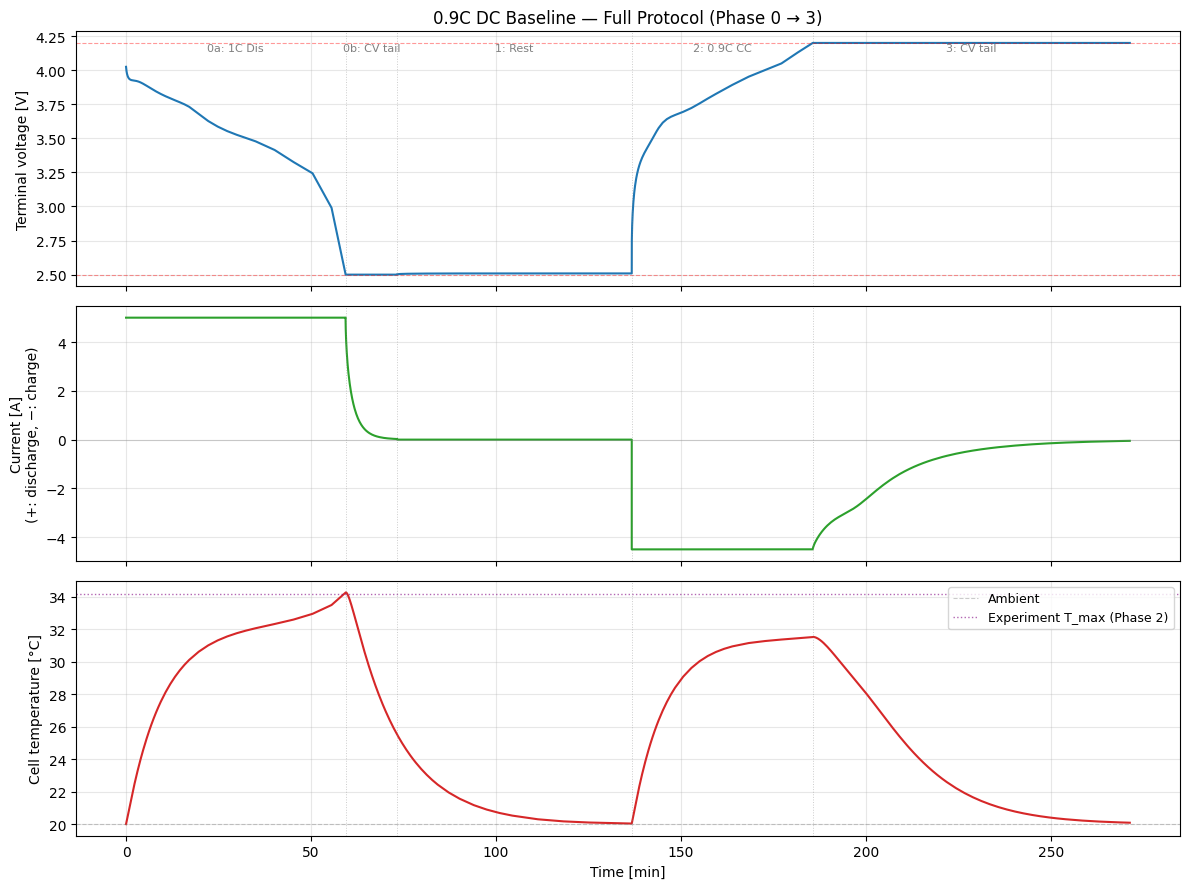

In [10]:
# Full-protocol visualization
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

t_all = solution.t / 60  # convert to minutes
V_all = solution["Terminal voltage [V]"].entries
I_all = solution["Current [A]"].entries
T_all = solution["X-averaged cell temperature [K]"].entries - 273.15

# Compute phase boundaries in minutes
phase_bounds = []
t_cumul = 0
for cycle in solution.cycles:
    duration = (cycle.t[-1] - cycle.t[0]) / 60
    t_cumul += duration
    phase_bounds.append(t_cumul)

# Voltage
ax1 = axes[0]
ax1.plot(t_all, V_all, linewidth=1.5, color='tab:blue')
ax1.set_ylabel("Terminal voltage [V]")
ax1.set_title("0.9C DC Baseline — Full Protocol (Phase 0 → 3)")
ax1.grid(True, alpha=0.3)
ax1.axhline(4.2, color='red', linestyle='--', alpha=0.4, linewidth=0.8)
ax1.axhline(2.5, color='red', linestyle='--', alpha=0.4, linewidth=0.8)

# Current
ax2 = axes[1]
ax2.plot(t_all, I_all, linewidth=1.5, color='tab:green')
ax2.set_ylabel("Current [A]\n(+: discharge, −: charge)")
ax2.grid(True, alpha=0.3)
ax2.axhline(0, color='gray', linestyle='-', alpha=0.3, linewidth=0.8)

# Temperature
ax3 = axes[2]
ax3.plot(t_all, T_all, linewidth=1.5, color='tab:red')
ax3.set_ylabel("Cell temperature [°C]")
ax3.set_xlabel("Time [min]")
ax3.grid(True, alpha=0.3)
ax3.axhline(20, color='gray', linestyle='--', alpha=0.4, linewidth=0.8, label='Ambient')
ax3.axhline(34.17, color='purple', linestyle=':', alpha=0.6, linewidth=1, label='Experiment T_max (Phase 2)')
ax3.legend(loc='upper right', fontsize=9)

# Phase boundaries on all subplots
phase_labels = ["0a: 1C Dis", "0b: CV tail", "1: Rest", "2: 0.9C CC", "3: CV tail"]
t_starts = [0] + phase_bounds[:-1]
t_ends = phase_bounds
for ax in axes:
    for ts in phase_bounds[:-1]:
        ax.axvline(ts, color='gray', linestyle=':', alpha=0.4, linewidth=0.7)

# Label phases on top axis
for i, (ts, te) in enumerate(zip(t_starts, t_ends)):
    mid = (ts + te) / 2
    axes[0].text(mid, axes[0].get_ylim()[1]*0.98, phase_labels[i],
                 ha='center', va='top', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('../figures/03_dc_baseline_full_protocol.png', dpi=150, bbox_inches='tight') if False else None
plt.show()

In [11]:
fig.savefig('../figures/03_dc_baseline_full_protocol.png', dpi=150, bbox_inches='tight')
print("Saved to ../figures/03_dc_baseline_full_protocol.png")

Saved to ../figures/03_dc_baseline_full_protocol.png
